In [1]:
import numpy as np
import random
import torch
import torch.nn.functional as F
import torch.nn as nn

from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_undirected
from torch_sparse import SparseTensor

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    normalized_mutual_info_score,
    adjusted_rand_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.cluster import SpectralClustering
from sklearn.cluster import KMeans

/home/snu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def setup_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

setup_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
fa_cn = np.load("/home/snu/Downloads/Histogram_CN_FA_20bin_updated.npy", allow_pickle=True)
fa_mci = np.load("/home/snu/Downloads/Histogram_MCI_FA_20bin_updated.npy", allow_pickle=True)

X = np.vstack([fa_cn, fa_mci]).astype(np.float32)
y = np.hstack([
    np.zeros(len(fa_cn), dtype=np.int64),
    np.ones(len(fa_mci), dtype=np.int64)
])
np.random.seed(42)
perm = np.random.permutation(X.shape[0])
X = X[perm]
y = y[perm]
N, F_dim = X.shape
print("Nodes:", N, "Features:", F_dim)

x = torch.from_numpy(X).to(device)
y_torch = torch.from_numpy(y).to(device)

Nodes: 300 Features: 180


In [4]:
def create_adj(features, alpha=0.92):
    f = features / np.linalg.norm(features, axis=1, keepdims=True)
    W = np.dot(f, f.T)
    W = (W >= alpha).astype(np.float32)
    return W

W = create_adj(X, alpha=0.92)

rows, cols = np.nonzero(W)
edge_index = torch.tensor([rows, cols], dtype=torch.long)
edge_index = to_undirected(edge_index).to(device)

adj = SparseTensor(
    row=edge_index[0],
    col=edge_index[1],
    sparse_sizes=(N, N)
).fill_value(1.).to(device)

/tmp/ipykernel_1635146/280809173.py:10: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:275.)
  edge_index = torch.tensor([rows, cols], dtype=torch.long)


In [5]:
def get_sim(batch, adj, wt=100, wl=2):     # wt - number of walks per node and wl - walk length
    rowptr, col, _ = adj.csr()
    batch_size = batch.shape[0]
    batch_repeat = batch.repeat(wt)
    rw = adj.random_walk(batch_repeat, wl)[:, 1:]
    rw = rw.t().reshape(-1, batch_size).t()

    row, col_, val = [], [], []
    for i in range(batch.shape[0]):
        rw_nodes, rw_times = torch.unique(rw[i], return_counts=True)
        row += [batch[i].item()] * rw_nodes.shape[0]
        col_ += rw_nodes.tolist()
        val += rw_times.tolist()

    adj_rw = SparseTensor(
        row=torch.tensor(row),
        col=torch.tensor(col_),
        value=torch.tensor(val),
        sparse_sizes=(batch.shape[0], batch.shape[0])
    )
    adj_rw = adj_rw.set_diag(0.)
    return adj_rw

In [6]:
def get_mask(adj):   # get_mask() - Remove weak edges
    mean = adj.mean(dim=1)
    mask = (adj.storage.value() -
            mean[adj.storage.row()]) > -1e-10
    return SparseTensor(
        row=adj.storage.row()[mask],
        col=adj.storage.col()[mask],
        value=adj.storage.value()[mask],
        sparse_sizes=adj.sizes()
    )

def scale(z): # scale() - Normalise embeddings
    zmin = z.min(dim=1, keepdim=True)[0]
    zmax = z.max(dim=1, keepdim=True)[0]
    return (z - zmin) / (zmax - zmin + 1e-12)

In [7]:
class MAGILoss(nn.Module):
    def __init__(self, tau=0.3):
        super().__init__()
        self.tau = tau

    def forward(self, z, mask):
        dot = torch.mm(z, z.t()) / self.tau
        dot = dot - dot.max(dim=1, keepdim=True)[0].detach()

        logits_mask = torch.ones_like(dot) - torch.eye(z.size(0), device=z.device)
        exp_logits = torch.exp(dot) * logits_mask
        log_prob = dot - torch.log(exp_logits.sum(1, keepdim=True))

        row, col = mask.storage.row(), mask.storage.col()
        loss = -log_prob[row, col].mean()
        return loss

In [8]:
class Encoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=256):
        super().__init__()
        self.conv = GCNConv(in_dim, hidden_dim)

    def forward(self, x, edge_index):
        x = self.conv(x, edge_index)
        x = F.leaky_relu(x, 0.5)
        return x

In [9]:
from sklearn.metrics import normalized_mutual_info_score  # <-- added

n_runs  = 10
epochs  = 5000

acc_list, prec_list, rec_list, f1_list, nmi_list = [], [], [], [], []  # <-- added nmi_list

for run in range(n_runs):
    print(f"\n========== Run {run+1}/{n_runs} ==========")

    setup_seed(42 + run)

    encoder   = Encoder(F_dim, 256).to(device)
    criterion = MAGILoss(tau=0.3)
    optimizer = torch.optim.Adam(
        encoder.parameters(), lr=5e-4, weight_decay=1e-3
    )

    batch  = torch.arange(N, device=device)
    adj_rw = get_sim(batch, adj)
    mask   = get_mask(adj_rw)

    for epoch in range(epochs):
        encoder.train()
        optimizer.zero_grad()

        z    = encoder(x, edge_index)
        z    = scale(z)
        z    = F.normalize(z, dim=1)
        loss = criterion(z, mask)
        loss.backward()
        optimizer.step()

        if epoch % 500 == 0:
            print(f"Run {run+1} | Epoch {epoch} | Loss {loss.item():.4f}")

    # -------------------- Evaluation (final model only) --------------------
    encoder.eval()
    with torch.no_grad():
        z = encoder(x, edge_index)
        z = scale(z)
        z = F.normalize(z, dim=1).cpu().numpy()

    kmeans = KMeans(n_clusters=2, n_init=20, random_state=run)
    y_pred = kmeans.fit_predict(z)

    acc1 = accuracy_score(y, y_pred)
    acc2 = accuracy_score(y, 1 - y_pred)
    if acc2 > acc1:
        y_pred = 1 - y_pred

    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec  = recall_score(y, y_pred,    zero_division=0)
    f1   = f1_score(y, y_pred,        zero_division=0)

    # ── NMI: one value per run, final model only ──
    nmi  = normalized_mutual_info_score(y, y_pred, average_method='arithmetic')

    acc_list.append(acc)
    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1)
    nmi_list.append(nmi)   # <-- added

    print(
        f"Run {run+1} → "
        f"ACC: {acc:.4f} | "
        f"PREC: {prec:.4f} | "
        f"REC: {rec:.4f} | "
        f"F1: {f1:.4f} | "
        f"NMI: {nmi:.4f}"    # <-- added
    )

print("\n===== MAGI + K-Means (10 Runs) =====")
print(f"ACC : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
print(f"PREC: {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
print(f"REC : {np.mean(rec_list):.4f} ± {np.std(rec_list):.4f}")
print(f"F1  : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
print(f"NMI : {np.mean(nmi_list):.4f} ± {np.std(nmi_list):.4f}")   # <-- added


========== Run 1/10 ==========
Run 1 | Epoch 0 | Loss 5.6747
Run 1 | Epoch 500 | Loss 5.1360
Run 1 | Epoch 1000 | Loss 5.1075
Run 1 | Epoch 1500 | Loss 5.0968
Run 1 | Epoch 2000 | Loss 5.0897
Run 1 | Epoch 2500 | Loss 5.0907
Run 1 | Epoch 3000 | Loss 5.0845
Run 1 | Epoch 3500 | Loss 5.0811
Run 1 | Epoch 4000 | Loss 5.0781
Run 1 | Epoch 4500 | Loss 5.0729
Run 1 → ACC: 0.7767 | PREC: 0.8571 | REC: 0.7186 | F1: 0.7818 | NMI: 0.2503

========== Run 2/10 ==========
Run 2 | Epoch 0 | Loss 5.6700
Run 2 | Epoch 500 | Loss 5.1298
Run 2 | Epoch 1000 | Loss 5.0996
Run 2 | Epoch 1500 | Loss 5.0890
Run 2 | Epoch 2000 | Loss 5.0834
Run 2 | Epoch 2500 | Loss 5.0813
Run 2 | Epoch 3000 | Loss 5.0745
Run 2 | Epoch 3500 | Loss 5.0690
Run 2 | Epoch 4000 | Loss 5.0647
Run 2 | Epoch 4500 | Loss 5.0670
Run 2 → ACC: 0.7733 | PREC: 0.8511 | REC: 0.7186 | F1: 0.7792 | NMI: 0.2426

========== Run 3/10 ==========
Run 3 | Epoch 0 | Loss 5.6774
Run 3 | Epoch 500 | Loss 5.1319
Run 3 | Epoch 1000 | Loss 5.1077
Run 3


========== Run 1/10 ==========
Run 1 | Epoch 0 | Loss 5.6747
Run 1 | Epoch 500 | Loss 5.1359
Run 1 | Epoch 1000 | Loss 5.1099
Run 1 | Epoch 1500 | Loss 5.0955
Run 1 | Epoch 2000 | Loss 5.0915
Run 1 | Epoch 2500 | Loss 5.0814
Run 1 | Epoch 3000 | Loss 5.0832
Run 1 | Epoch 3500 | Loss 5.0800
Run 1 | Epoch 4000 | Loss 5.0810
Run 1 | Epoch 4500 | Loss 5.0784
Run 1 → ACC:0.7767 | PREC:0.8571 | REC:0.7186 | F1:0.7818 | NMI:0.2503

========== Run 2/10 ==========
Run 2 | Epoch 0 | Loss 5.6700
Run 2 | Epoch 500 | Loss 5.1295
Run 2 | Epoch 1000 | Loss 5.1030
Run 2 | Epoch 1500 | Loss 5.0922
Run 2 | Epoch 2000 | Loss 5.0850
Run 2 | Epoch 2500 | Loss 5.0749
Run 2 | Epoch 3000 | Loss 5.0712
Run 2 | Epoch 3500 | Loss 5.0681
Run 2 | Epoch 4000 | Loss 5.0659
Run 2 | Epoch 4500 | Loss 5.0638
Run 2 → ACC:0.7733 | PREC:0.8511 | REC:0.7186 | F1:0.7792 | NMI:0.2426

========== Run 3/10 ==========
Run 3 | Epoch 0 | Loss 5.6774
Run 3 | Epoch 500 | Loss 5.1321
Run 3 | Epoch 1000 | Loss 5.1078
Run 3 | Epoch 1

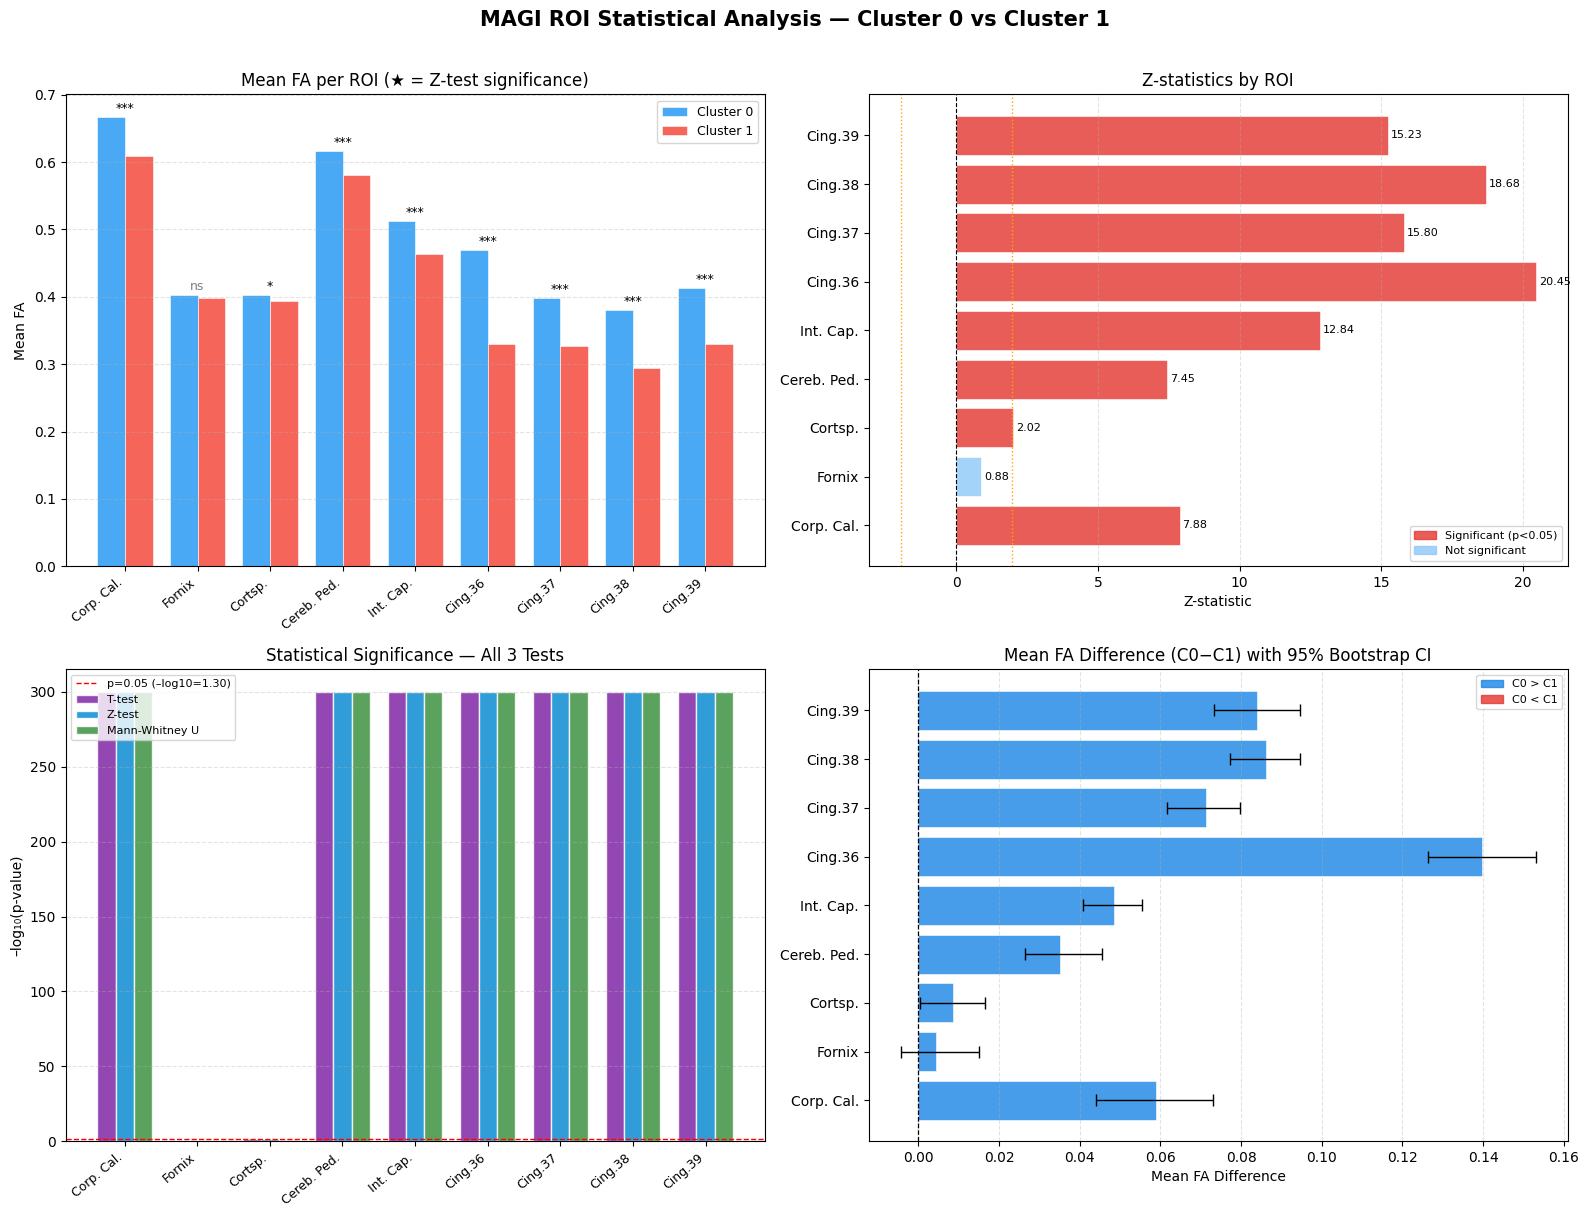

Saved: magi_roi_combined_stats.png


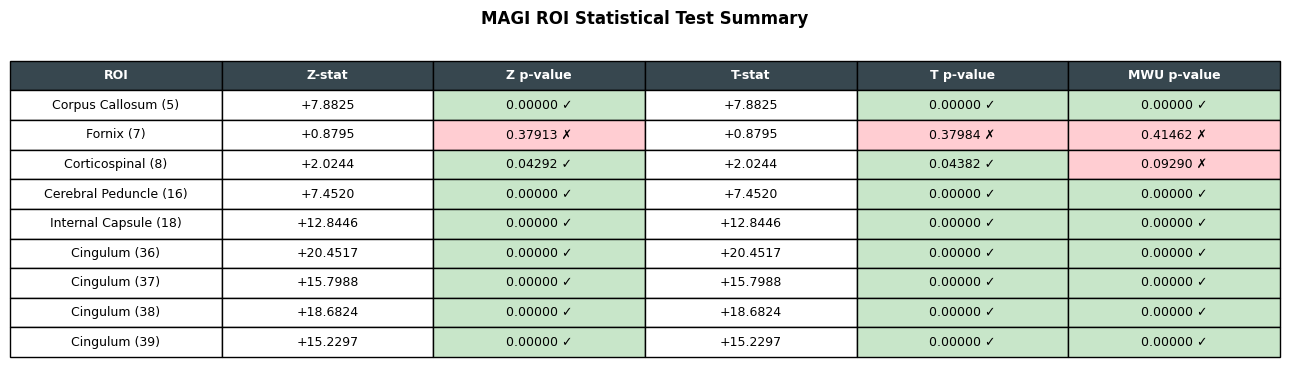

Saved: magi_roi_pvalue_table.png


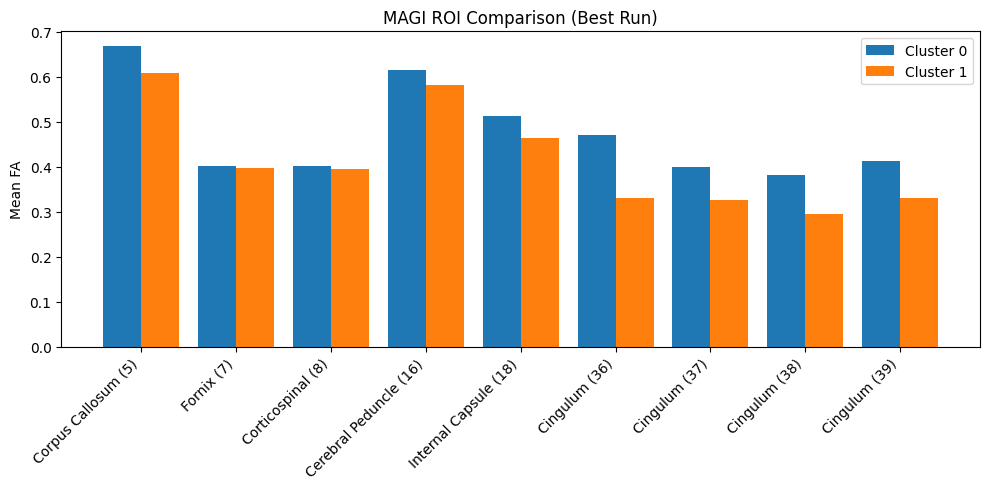

Saved: magi_roi_barplot.png


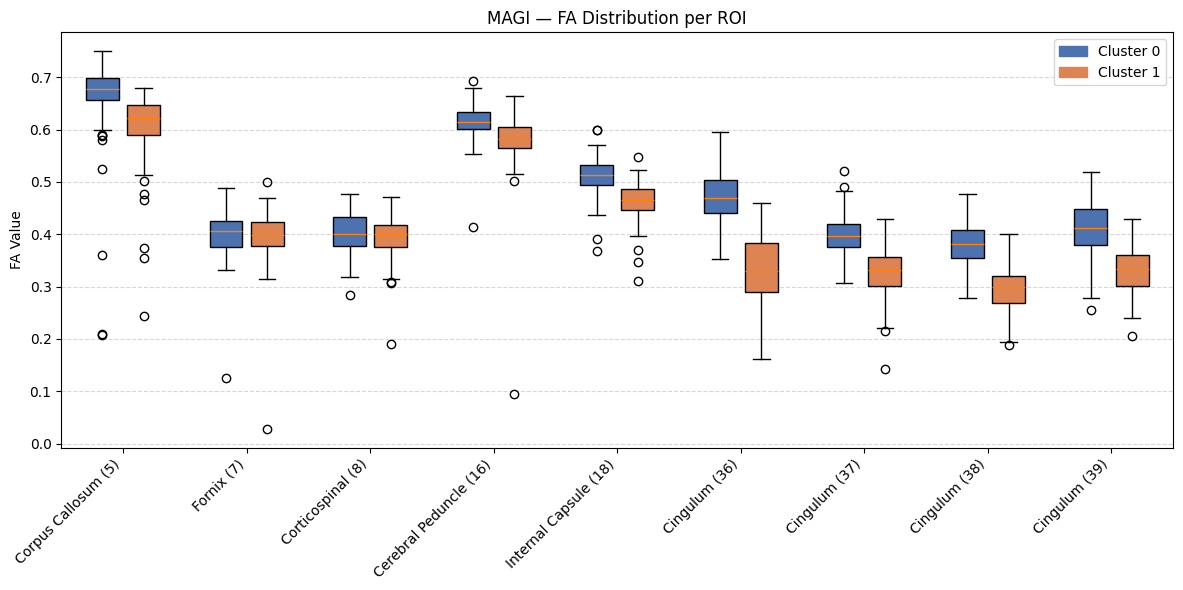

Saved: magi_roi_boxplot.png


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch
import torch.nn.functional as F
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, normalized_mutual_info_score
)
from collections import Counter
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.weightstats import ztest

# ════════════════════════════════════════════════════════════════════
#  ROI CONFIG
# ════════════════════════════════════════════════════════════════════
num_rois     = 9
bins_per_roi = 20

roi_names = [
    "Corpus Callosum (5)", "Fornix (7)", "Corticospinal (8)",
    "Cerebral Peduncle (16)", "Internal Capsule (18)",
    "Cingulum (36)", "Cingulum (37)", "Cingulum (38)", "Cingulum (39)"
]
short_names = [
    "Corp. Cal.", "Fornix", "Cortsp.",
    "Cereb. Ped.", "Int. Cap.",
    "Cing.36", "Cing.37", "Cing.38", "Cing.39"
]

roi_indices = {
    roi_names[i]: (i * bins_per_roi, (i + 1) * bins_per_roi)
    for i in range(num_rois)
}

bin_edges   = np.linspace(0, 1, bins_per_roi + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# ════════════════════════════════════════════════════════════════════
#  MAGI MULTI-RUN
# ════════════════════════════════════════════════════════════════════
n_runs  = 10
epochs  = 5000

acc_list, prec_list, rec_list  = [], [], []
f1_list, nmi_list              = [], []

best_acc   = -1
best_pred  = None        # y_pred from best run
best_z     = None        # embeddings from best run

for run in range(n_runs):
    print(f"\n========== Run {run+1}/{n_runs} ==========")

    setup_seed(42 + run)

    encoder   = Encoder(F_dim, 256).to(device)
    criterion = MAGILoss(tau=0.3)
    optimizer = torch.optim.Adam(
        encoder.parameters(), lr=5e-4, weight_decay=1e-3
    )

    batch  = torch.arange(N, device=device)
    adj_rw = get_sim(batch, adj)
    mask   = get_mask(adj_rw)

    for epoch in range(epochs):
        encoder.train()
        optimizer.zero_grad()

        z    = encoder(x, edge_index)
        z    = scale(z)
        z    = F.normalize(z, dim=1)
        loss = criterion(z, mask)
        loss.backward()
        optimizer.step()

        if epoch % 500 == 0:
            print(f"Run {run+1} | Epoch {epoch} | Loss {loss.item():.4f}")

    # ── Evaluation ───────────────────────────────────────────────
    encoder.eval()
    with torch.no_grad():
        z = encoder(x, edge_index)
        z = scale(z)
        z = F.normalize(z, dim=1).cpu().numpy()

    kmeans = KMeans(n_clusters=2, n_init=20, random_state=run)
    y_pred = kmeans.fit_predict(z)

    acc1 = accuracy_score(y, y_pred)
    acc2 = accuracy_score(y, 1 - y_pred)
    if acc2 > acc1:
        y_pred = 1 - y_pred

    acc  = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec  = recall_score(y, y_pred,    zero_division=0)
    f1   = f1_score(y, y_pred,        zero_division=0)
    nmi  = normalized_mutual_info_score(y, y_pred, average_method='arithmetic')

    acc_list.append(acc);  prec_list.append(prec)
    rec_list.append(rec);  f1_list.append(f1)
    nmi_list.append(nmi)

    print(f"Run {run+1} → ACC:{acc:.4f} | PREC:{prec:.4f} | "
          f"REC:{rec:.4f} | F1:{f1:.4f} | NMI:{nmi:.4f}")

    if acc > best_acc:
        best_acc  = acc
        best_pred = y_pred.copy()
        best_z    = z.copy()

# ════════════════════════════════════════════════════════════════════
#  SUMMARY
# ════════════════════════════════════════════════════════════════════
print("\n===== MAGI + K-Means (10 Runs) =====")
print(f"ACC : {np.mean(acc_list):.4f} ± {np.std(acc_list):.4f}")
print(f"PREC: {np.mean(prec_list):.4f} ± {np.std(prec_list):.4f}")
print(f"REC : {np.mean(rec_list):.4f} ± {np.std(rec_list):.4f}")
print(f"F1  : {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")
print(f"NMI : {np.mean(nmi_list):.4f} ± {np.std(nmi_list):.4f}")

# ── Save labels ───────────────────────────────────────────────────
np.save("/home/snu/Downloads/magi_labels.npy", best_pred)
print("\nSaved: magi_labels.npy")
print("Shape:", best_pred.shape)
print("Unique:", np.unique(best_pred))

# ════════════════════════════════════════════════════════════════════
#  COMMUNITY ANALYSIS
# ════════════════════════════════════════════════════════════════════
print("\n===== COMMUNITY LEVEL ANALYSIS (MAGI) =====\n")
for k in range(2):
    print(f"Cluster {k}:", Counter(y[best_pred == k]))

# ════════════════════════════════════════════════════════════════════
#  COMPUTE ALL STATS  (T-test, Z-test, Mann-Whitney U)
# ════════════════════════════════════════════════════════════════════
# NOTE: ROI stats use original X (same node order — MAGI does not permute)
roi_stats = {}
for roi, (start, end) in roi_indices.items():
    vals = []
    for k in range(2):
        roi_hist = X[best_pred == k, start:end]
        weighted = (roi_hist * bin_centers).sum(axis=1)
        vals.append(weighted.mean())
    roi_stats[roi] = vals

records = []
for roi, (start, end) in roi_indices.items():
    c0_vals = (X[best_pred == 0, start:end] * bin_centers).sum(axis=1)
    c1_vals = (X[best_pred == 1, start:end] * bin_centers).sum(axis=1)

    mean_c0 = c0_vals.mean()
    mean_c1 = c1_vals.mean()
    diff    = mean_c0 - mean_c1

    t_stat, t_pval = ttest_ind(c0_vals, c1_vals)
    z_stat, z_pval = ztest(c0_vals, c1_vals, value=0)
    u_stat, u_pval = mannwhitneyu(c0_vals, c1_vals, alternative='two-sided')

    records.append({
        "ROI":     roi,
        "Mean_C0": round(mean_c0, 4),
        "Mean_C1": round(mean_c1, 4),
        "Diff":    round(diff, 4),
        "T_stat":  round(t_stat, 4),
        "T_pval":  round(t_pval, 6),
        "T_sig":   t_pval < 0.05,
        "Z_stat":  round(z_stat, 4),
        "Z_pval":  round(z_pval, 6),
        "Z_sig":   z_pval < 0.05,
        "U_stat":  round(u_stat, 4),
        "U_pval":  round(u_pval, 6),
        "U_sig":   u_pval < 0.05,
    })

df = pd.DataFrame(records)

# ── Save CSV ──────────────────────────────────────────────────────
df.to_csv("/home/snu/Downloads/magi_roi_stats.csv", index=False)
print("\nSaved: magi_roi_stats.csv")
print(df.to_string(index=False))

# ── Print tables ──────────────────────────────────────────────────
print("\nStatistical Significance (T-test):\n")
print(f"{'ROI':<30} | {'T-stat':>10} | {'P-value':>10} | {'Significant':>12}")
print("-" * 70)
for _, row in df.iterrows():
    sig = "Yes ✓" if row["T_sig"] else "No"
    print(f"{row['ROI']:<30} | {row['T_stat']:>10.4f} | "
          f"{row['T_pval']:>10.5f} | {sig:>12}")

print("\nStatistical Significance (2-Sample Z-test):\n")
print(f"{'ROI':<30} | {'Z-stat':>10} | {'P-value':>10} | {'Significant':>12}")
print("-" * 70)
for _, row in df.iterrows():
    sig = "Yes ✓" if row["Z_sig"] else "No"
    print(f"{row['ROI']:<30} | {row['Z_stat']:>10.4f} | "
          f"{row['Z_pval']:>10.5f} | {sig:>12}")

# ════════════════════════════════════════════════════════════════════
#  COMBINED 4-PANEL FIGURE
# ════════════════════════════════════════════════════════════════════
x_pos = np.arange(len(roi_names))
width = 0.38
alpha = 0.82

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "MAGI ROI Statistical Analysis — Cluster 0 vs Cluster 1",
    fontsize=15, fontweight='bold', y=1.01
)

# ── Panel 1 : Mean FA bar chart ───────────────────────────────────
ax = axes[0, 0]
ax.bar(x_pos - width/2, df["Mean_C0"], width, label="Cluster 0",
       color="#2196F3", alpha=alpha, edgecolor='white', linewidth=0.5)
ax.bar(x_pos + width/2, df["Mean_C1"], width, label="Cluster 1",
       color="#F44336", alpha=alpha, edgecolor='white', linewidth=0.5)

for i, row in df.iterrows():
    stars = ("***" if row["Z_pval"] < 0.001 else
             "**"  if row["Z_pval"] < 0.01  else
             "*"   if row["Z_pval"] < 0.05  else "ns")
    ymax  = max(row["Mean_C0"], row["Mean_C1"]) + 0.003
    ax.text(i, ymax, stars, ha='center', va='bottom', fontsize=9,
            color='black' if stars != "ns" else 'gray')

ax.set_xticks(x_pos)
ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=9)
ax.set_ylabel("Mean FA")
ax.set_title("Mean FA per ROI (★ = Z-test significance)")
ax.legend(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.35)

# ── Panel 2 : Z-statistics ────────────────────────────────────────
ax       = axes[0, 1]
colors_z = ["#E53935" if s else "#90CAF9" for s in df["Z_sig"]]
bars     = ax.barh(short_names, df["Z_stat"], color=colors_z,
                   edgecolor='white', linewidth=0.5, alpha=alpha)
ax.axvline(0,     color='black',  linewidth=0.8, linestyle='--')
ax.axvline(-1.96, color='orange', linewidth=1,   linestyle=':',
           label='±1.96 threshold')
ax.axvline( 1.96, color='orange', linewidth=1,   linestyle=':')

for bar, val in zip(bars, df["Z_stat"]):
    ax.text(val - 0.3 if val < 0 else val + 0.1,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va='center',
            ha='right' if val < 0 else 'left', fontsize=8)

sig_patch   = mpatches.Patch(color='#E53935', alpha=alpha, label='Significant (p<0.05)')
unsig_patch = mpatches.Patch(color='#90CAF9', alpha=alpha, label='Not significant')
ax.legend(handles=[sig_patch, unsig_patch], fontsize=8, loc='lower right')
ax.set_title("Z-statistics by ROI")
ax.set_xlabel("Z-statistic")
ax.grid(axis='x', linestyle='--', alpha=0.35)

# ── Panel 3 : –log10(p-value) all 3 tests ────────────────────────
ax    = axes[1, 0]
log_t = -np.log10(df["T_pval"].clip(lower=1e-300))
log_z = -np.log10(df["Z_pval"].clip(lower=1e-300))
log_u = -np.log10(df["U_pval"].clip(lower=1e-300))
w3    = 0.25

ax.bar(x_pos - w3, log_t, w3, label="T-test",
       color="#7B1FA2", alpha=alpha, edgecolor='white')
ax.bar(x_pos,      log_z, w3, label="Z-test",
       color="#0288D1", alpha=alpha, edgecolor='white')
ax.bar(x_pos + w3, log_u, w3, label="Mann-Whitney U",
       color="#388E3C", alpha=alpha, edgecolor='white')

threshold_line = -np.log10(0.05)
ax.axhline(threshold_line, color='red', linestyle='--', linewidth=1,
           label=f'p=0.05 (–log10={threshold_line:.2f})')

ax.set_xticks(x_pos)
ax.set_xticklabels(short_names, rotation=40, ha='right', fontsize=9)
ax.set_ylabel("–log₁₀(p-value)")
ax.set_title("Statistical Significance — All 3 Tests")
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.35)

# ── Panel 4 : Signed mean diff + bootstrap CI ─────────────────────
ax = axes[1, 1]
np.random.seed(42)
ci_low, ci_high = [], []
for roi, (start, end) in roi_indices.items():
    c0v = (X[best_pred == 0, start:end] * bin_centers).sum(axis=1)
    c1v = (X[best_pred == 1, start:end] * bin_centers).sum(axis=1)
    boot_diffs = [
        np.random.choice(c0v, len(c0v), replace=True).mean() -
        np.random.choice(c1v, len(c1v), replace=True).mean()
        for _ in range(1000)
    ]
    ci_low.append(np.percentile(boot_diffs, 2.5))
    ci_high.append(np.percentile(boot_diffs, 97.5))

diffs    = df["Diff"].values
err_low  = diffs - np.array(ci_low)
err_high = np.array(ci_high) - diffs
colors_d = ["#E53935" if d < 0 else "#1E88E5" for d in diffs]

ax.barh(short_names, diffs,
        xerr=[err_low, err_high],
        color=colors_d, alpha=alpha,
        edgecolor='white', linewidth=0.5,
        error_kw=dict(ecolor='black', capsize=4, linewidth=1))
ax.axvline(0, color='black', linewidth=0.9, linestyle='--')
ax.set_title("Mean FA Difference (C0−C1) with 95% Bootstrap CI")
ax.set_xlabel("Mean FA Difference")
ax.grid(axis='x', linestyle='--', alpha=0.35)

pos_patch = mpatches.Patch(color='#1E88E5', alpha=alpha, label='C0 > C1')
neg_patch = mpatches.Patch(color='#E53935', alpha=alpha, label='C0 < C1')
ax.legend(handles=[pos_patch, neg_patch], fontsize=8)

plt.tight_layout()
plt.savefig("/home/snu/Downloads/magi_roi_combined_stats.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: magi_roi_combined_stats.png")

# ════════════════════════════════════════════════════════════════════
#  P-VALUE SUMMARY TABLE AS IMAGE
# ════════════════════════════════════════════════════════════════════
fig2, ax2 = plt.subplots(figsize=(13, 4))
ax2.axis('off')

table_data = []
for _, row in df.iterrows():
    def fmt(pval, sig):
        return f"{pval:.5f} {'✓' if sig else '✗'}"
    table_data.append([
        row["ROI"],
        f"{row['Z_stat']:+.4f}",
        fmt(row["Z_pval"], row["Z_sig"]),
        f"{row['T_stat']:+.4f}",
        fmt(row["T_pval"], row["T_sig"]),
        fmt(row["U_pval"], row["U_sig"]),
    ])

col_labels = ["ROI", "Z-stat", "Z p-value", "T-stat", "T p-value", "MWU p-value"]
tbl = ax2.table(
    cellText=table_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)

for (row_idx, col_idx), cell in tbl.get_celld().items():
    if row_idx == 0:
        cell.set_facecolor('#37474F')
        cell.set_text_props(color='white', fontweight='bold')
    elif col_idx in [2, 4, 5]:
        txt = cell.get_text().get_text()
        cell.set_facecolor('#C8E6C9' if '✓' in txt else '#FFCDD2')

ax2.set_title("MAGI ROI Statistical Test Summary",
              fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig("/home/snu/Downloads/magi_roi_pvalue_table.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: magi_roi_pvalue_table.png")

# ════════════════════════════════════════════════════════════════════
#  BAR PLOT
# ════════════════════════════════════════════════════════════════════
roi_means_c0 = [roi_stats[r][0] for r in roi_names]
roi_means_c1 = [roi_stats[r][1] for r in roi_names]

plt.figure(figsize=(10, 5))
plt.bar(x_pos - 0.2, roi_means_c0, width=0.4, label="Cluster 0")
plt.bar(x_pos + 0.2, roi_means_c1, width=0.4, label="Cluster 1")
plt.xticks(x_pos, roi_names, rotation=45, ha='right')
plt.ylabel("Mean FA")
plt.title("MAGI ROI Comparison (Best Run)")
plt.legend()
plt.tight_layout()
plt.savefig("/home/snu/Downloads/magi_roi_barplot.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: magi_roi_barplot.png")

# ════════════════════════════════════════════════════════════════════
#  BOX PLOT
# ════════════════════════════════════════════════════════════════════
color_c0 = "#4C72B0"
color_c1 = "#DD8452"

plt.figure(figsize=(12, 6))
positions, data, colors = [], [], []
gap, bw = 1.5, 0.5

for i, (roi, (start, end)) in enumerate(roi_indices.items()):
    c0 = (X[best_pred == 0, start:end] * bin_centers).sum(axis=1)
    c1 = (X[best_pred == 1, start:end] * bin_centers).sum(axis=1)
    positions += [i * gap, i * gap + bw]
    data      += [c0, c1]
    colors    += [color_c0, color_c1]

box = plt.boxplot(data, positions=positions, widths=0.4, patch_artist=True)
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

xticks = [i * gap + bw / 2 for i in range(len(roi_names))]
plt.xticks(xticks, roi_names, rotation=45, ha='right')
plt.ylabel("FA Value")
plt.title("MAGI — FA Distribution per ROI")
plt.legend(
    handles=[
        plt.Rectangle((0, 0), 1, 1, color=color_c0),
        plt.Rectangle((0, 0), 1, 1, color=color_c1)
    ],
    labels=["Cluster 0", "Cluster 1"]
)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("/home/snu/Downloads/magi_roi_boxplot.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: magi_roi_boxplot.png")